In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import sys
sys.path.append("/home/geraldine/Documents/Research/Projects/BayesGPT/")
print(sys.path)

['/home/a_huangm13/Documents/Research/Projects/BayesGPT', '/home/a_huangm13/Documents/Research/Projects/BayesGPT/bayesgpt', '/home/a_huangm13/Documents/Research/Projects/BayesGPT/tests', '/home/a_huangm13/.local/share/JetBrains/Toolbox/apps/pycharm/plugins/python-ce/helpers/pydev', '/home/a_huangm13/.local/share/JetBrains/Toolbox/apps/pycharm/plugins/python-ce/helpers/jupyter_debug', '/home/a_huangm13/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python311.zip', '/home/a_huangm13/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11', '/home/a_huangm13/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/lib-dynload', '', '/home/a_huangm13/Documents/Research/Projects/BayesGPT/.venv/lib/python3.11/site-packages', '/home/a_huangm13/Documents/Research/Projects/BayesGPT/.venv/lib/python3.11/site-packages/setuptools/_vendor', '/home/geraldine/Documents/Research/Projects/BayesGPT/', '/home/geraldine/Documents/Research/Projects/BayesGPT/']


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
from bayesgpt.simulators.benchmarks import DDM, CDM, RDM
from bayesgpt.simulators.benchmarks.ddms.ddm_priors import ddm_full_priors, ddm_baseline_priors
from bayesgpt.simulators.benchmarks.rdms.rdm_priors import rdm_full_priors
from bayesgpt.simulators.benchmarks.cdms.cdm_priors import cdm_full_priors

In [34]:
from bayesgpt.simulators import NestedModelFamily

In [35]:
ddm_family = NestedModelFamily(
    name='DDM',
    model=DDM(),
    prior_fun=ddm_baseline_priors(),
    mask_randomizer_kwargs=dict(
        free_intrinsics=["v", "a", "tau", "s_v", "s_tau"],
        fixed_intrinsics=[],
        fixed_values={}
    ),
)

### Prior predictive check

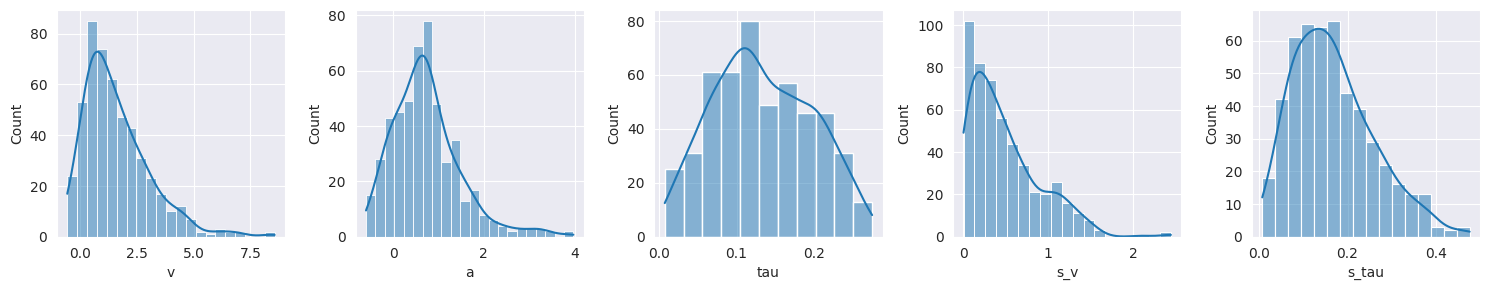

In [39]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau"]
regressed_params = ["v", "a"]

design_config = {
    "1": intrinsic_params,
    "u_1": regressed_params,
    "u_2": regressed_params,
    "u_1:u_2": regressed_params,
}

out = ddm_family.check_regressed_priors(
    design_config=design_config,
    num_draws=500,
    num_obs=200,
    keep_intercept=True,
    max_num_categories=4,
    run_simulator=False,
    plot=True,
)

# theta = out["theta_draws"]        # (draws, obs, intrinsic_params)
# coef  = out.get("coef_draws", None)
# labels = out["column_labels"]

In [28]:
type(out["sim_draws"][0])

dict

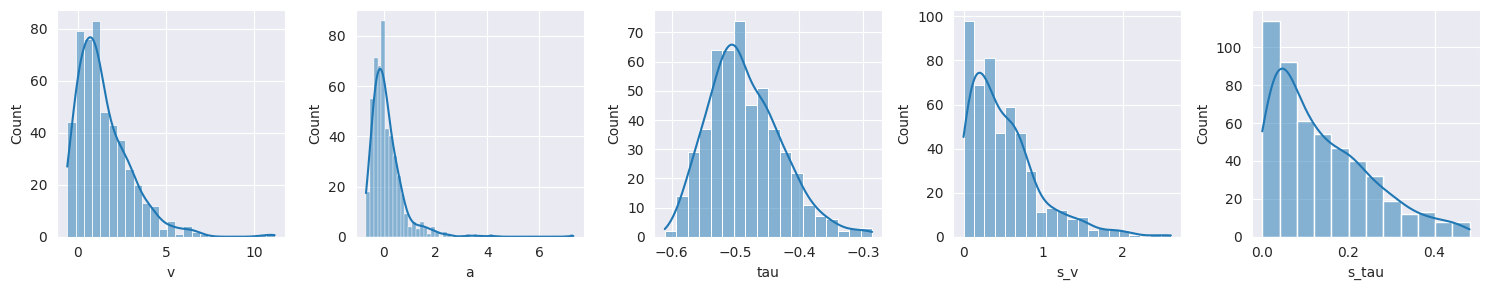

In [22]:
out

In [13]:
theta[:,0,:]

array([[ 1.38412476e-01, -5.87729365e-02, -5.46826184e-01,
         1.44596085e-01,  8.34138095e-02],
       [ 2.60529971e+00, -5.73626943e-02, -5.27098119e-01,
         1.07173812e+00,  1.42021561e-02],
       [ 1.23125219e+00,  6.74353302e-01, -4.92271304e-01,
         4.70500648e-01,  1.33606023e-04],
       ...,
       [ 4.30589819e+00, -1.28243029e-01, -4.30276811e-01,
         8.93378019e-01,  3.07986438e-01],
       [ 2.11138055e-01,  3.06758046e-01, -3.46078455e-01,
         7.59354949e-01,  2.24609271e-01],
       [-1.17297046e-01, -1.09784402e-01, -4.98335630e-01,
         6.37213409e-01,  1.31841615e-01]], shape=(500, 5), dtype=float32)

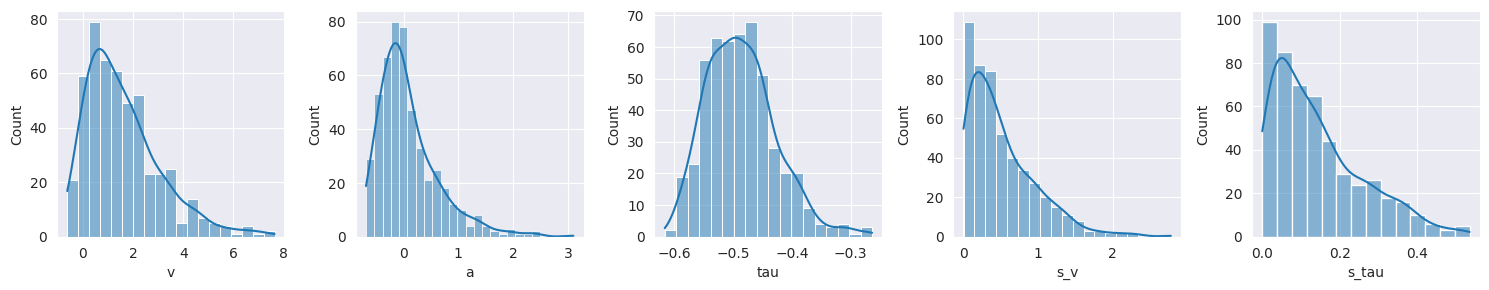

In [17]:
f, axarr = plt.subplots(1, len(intrinsic_params), figsize=(15, 3))

for i, ax in enumerate(axarr):
    sns.histplot(theta[:,0,i], ax=ax, kde=True)
    ax.set_xlabel(intrinsic_params[i])

f.tight_layout()

### Sampling

In [16]:
ddm_samples = ddm_family.batch_sample(
    batch_size=10,
    num_obs=500,
    max_num_regressors=3,
    max_num_categories=3,
    flatten_param_outputs=False,
    add_interaction=True
)

ValueError: could not broadcast input array from shape (500,5) into shape (500,7)

In [10]:
for k, v in ddm_samples.items():
    print(k, v.shape if isinstance(v, np.ndarray) else (len(v.keys()) if isinstance(v, dict) else v))

model_names ['DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM']
design_configs [{'1': ['v', 'a', 'tau', 's_v', 's_tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['v']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['a']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['a', 'tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['a'], 'u_2': ['v', 'tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['a']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau']}, {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['v', 'a'], 'u_2': ['tau']}]
design_matrices (10, 500, 3)
param_masks (10, 3, 5)
param_matrices (10, 3, 5)
sim_data 2
regressor_masks (10, 3)
discrete_masks (10, 2)
num_obs (10, 1)
num_regressors (10, 1)
max_num_regressors 2
max_num_categories 2


In [10]:
ddm_samples["param_matrices"]

array([[[ 1.27350205, -0.05655673, -1.37022512,  0.        ,
          0.        ],
        [-1.42732181,  1.90347146,  0.        ,  0.        ,
          0.        ],
        [-0.18032252, -1.89871266,  0.        ,  0.        ,
          0.        ],
        [ 0.        , -1.07173546,  0.01829549,  0.        ,
          0.        ],
        [ 0.        ,  0.65300486,  1.33071715,  0.        ,
          0.        ],
        [ 0.        ,  0.        , -0.52755625,  0.        ,
          0.        ],
        [ 0.        ,  0.        , -0.90823565,  0.        ,
          0.        ]],

       [[ 4.30241914, -0.31070726, -1.63034614,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,
          0. 

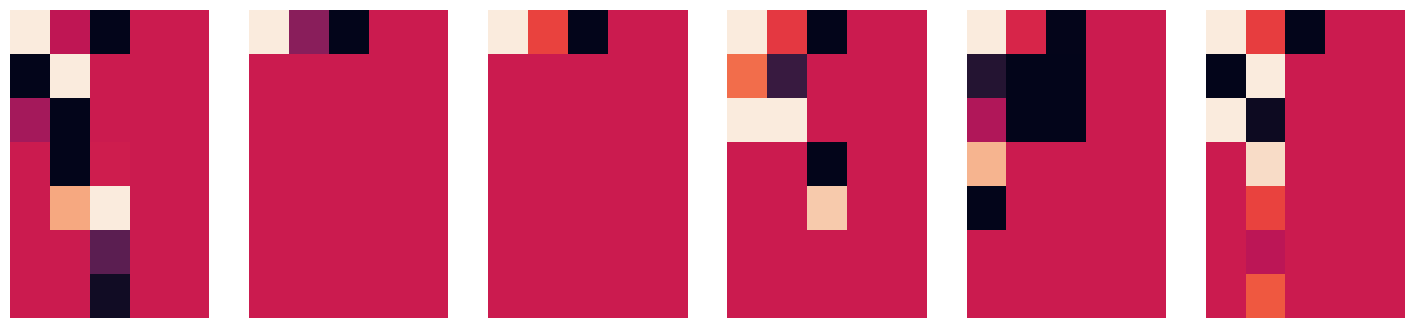

In [11]:
f, axarr = plt.subplots(1, 6, figsize=(18, 4))
for i, ax in enumerate(axarr.flat):
    sns.heatmap(ddm_samples["param_matrices"][i], cbar=False, xticklabels=False, yticklabels=False, ax=ax, vmin=-1, vmax=1)

In [21]:
rdm_family = NestedModelFamily(
    name='RDM',
    model=RDM(),
    prior_fun=ddm_full_priors()
)

In [46]:
rdm_samples = rdm_family.batch_sample(
    batch_size=6,
    num_obs=500,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "v_diff", "a", "tau", "decay"},
        fixed_intrinsics={}
    ),
    flatten_param_outputs=False
)

TypeError: 'float' object is not callable

In [37]:
cdm_family = NestedModelFamily(
    name='CDM',
    model=CDM(),
    prior_fun=cdm_full_priors()
)

In [38]:
cdm_samples = cdm_family.batch_sample(
    batch_size=6,
    num_obs=500,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "decay", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    flatten_param_outputs=False
)

TypeError: 'float' object is not callable

### Data exploration

<Axes: ylabel='Count'>

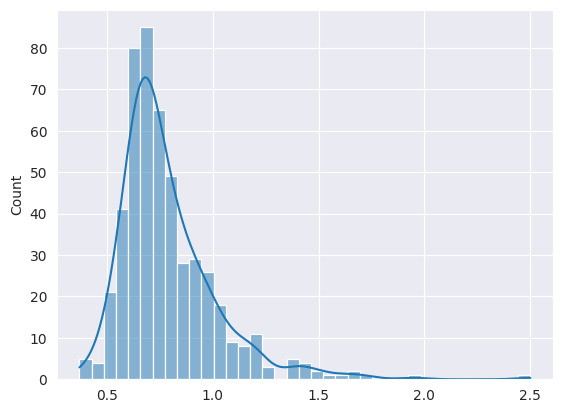

In [20]:
sns.histplot(samples["sim_data"]["rts"][0], kde=True, legend=False)